In [3]:
# ----------------------------------
# Import Libraries
# ----------------------------------

import os
import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kurtosis

sns.set_theme(style="whitegrid")

In [4]:
# ----------------------------------
# Locate IMS Files
# ----------------------------------

folder_path = r"C:\Users\Nill\Desktop\Da\4. Bearings\IMS\2nd\2nd_test"

files = sorted(

    glob.glob(

        os.path.join(folder_path, "*")

    )

)

print("Number of Files:", len(files))

print("\nFirst Five Files:")

for file in files[:5]:

    print(os.path.basename(file))

Number of Files: 984

First Five Files:
2004.02.12.10.32.39
2004.02.12.10.42.39
2004.02.12.10.52.39
2004.02.12.11.02.39
2004.02.12.11.12.39


In [5]:
# ----------------------------------
# Load One Vibration File
# ----------------------------------

sample = pd.read_csv(

    files[0],

    sep="\t",

    header=None

)

sample.columns = [

    "Bearing_1",

    "Bearing_2",

    "Bearing_3",

    "Bearing_4"

]

sample.head()

,Bearing_1,Bearing_2,Bearing_3,Bearing_4
0,-0.049,-0.071,-0.132,-0.010
1,-0.042,-0.073,-0.007,-0.105
2,0.015,0.000,0.007,0.000
3,-0.051,0.020,-0.002,0.100
4,-0.107,0.010,0.127,0.054


In [6]:
sample.shape

(20480, 4)

In [7]:
# ----------------------------------
# Feature Extraction Function
# ----------------------------------

def extract_features(signal):

    rms = np.sqrt(

        np.mean(signal**2)

    )

    peak = np.max(

        np.abs(signal)

    )

    std = np.std(signal)

    kurt = kurtosis(signal)

    crest = peak / rms

    return rms, peak, std, kurt, crest

In [8]:
# ----------------------------------
# Test Feature Extraction
# ----------------------------------

rms, peak, std, kurt, crest = extract_features(

    sample["Bearing_1"]

)

print("RMS:", rms)
print("Peak:", peak)
print("Standard Deviation:", std)
print("Kurtosis:", kurt)
print("Crest Factor:", crest)

RMS: 0.07417899856512623
Peak: 0.454
Standard Deviation: 0.07347493104305139
Kurtosis: 0.6287626426442561
Crest Factor: 6.120330670161392


In [9]:
# ----------------------------------
# Extract Features From All Files
# ----------------------------------

records = []

for file in files:

    data = pd.read_csv(

        file,

        sep="\t",

        header=None

    )

    data.columns = [

        "Bearing_1",

        "Bearing_2",

        "Bearing_3",

        "Bearing_4"

    ]

    row = {

        "File": os.path.basename(file)

    }

    for bearing in data.columns:

        rms, peak, std, kurt, crest = extract_features(

            data[bearing]

        )

        row[f"{bearing}_RMS"] = rms
        row[f"{bearing}_Peak"] = peak
        row[f"{bearing}_STD"] = std
        row[f"{bearing}_Kurtosis"] = kurt
        row[f"{bearing}_Crest"] = crest

    records.append(row)

ims_features = pd.DataFrame(records)

ims_features.head()

,File,Bearing_1_RMS,Bearing_1_Peak,Bearing_1_STD,Bearing_1_Kurtosis,Bearing_1_Crest,Bearing_2_RMS,Bearing_2_Peak,Bearing_2_STD,Bearing_2_Kurtosis,...,Bearing_3_RMS,Bearing_3_Peak,Bearing_3_STD,Bearing_3_Kurtosis,Bearing_3_Crest,Bearing_4_RMS,Bearing_4_Peak,Bearing_4_STD,Bearing_4_Kurtosis,Bearing_4_Crest
0,2004.02.12.10.32.39,0.074179,0.454,0.073475,0.628763,6.120331,0.090944,0.513,0.090053,0.506801,...,0.109404,1.023,0.108434,3.213075,9.350652,0.054103,0.264,0.053166,0.065959,4.879539
1,2004.02.12.10.42.39,0.075382,0.388,0.075338,0.648291,5.147086,0.093419,0.481,0.093384,0.253014,...,0.109817,0.752,0.109790,1.395250,6.847735,0.056101,0.249,0.055973,0.107539,4.438435
2,2004.02.12.10.52.39,0.076230,0.503,0.076189,0.513475,6.598472,0.093718,0.503,0.093703,0.310789,...,0.109861,0.933,0.109849,2.639948,8.492546,0.056145,0.354,0.056037,0.257236,6.305078
3,2004.02.12.11.02.39,0.078724,0.608,0.078691,1.157953,7.723217,0.092947,0.569,0.092916,0.235341,...,0.110667,1.016,0.110622,2.682779,9.180734,0.056807,0.525,0.056684,0.806190,9.241749
4,2004.02.12.11.12.39,0.078474,0.391,0.078437,0.603177,4.982524,0.095348,0.486,0.095335,0.226309,...,0.107506,0.771,0.107499,1.578395,7.171719,0.056841,0.244,0.056777,0.138954,4.292680


In [10]:
ims_features.shape

(984, 21)

In [11]:
# ----------------------------------
# Check Extracted Dataset
# ----------------------------------

print(ims_features.shape)

ims_features.head()

ims_features.describe()

(984, 21)


,Bearing_1_RMS,Bearing_1_Peak,Bearing_1_STD,Bearing_1_Kurtosis,Bearing_1_Crest,Bearing_2_RMS,Bearing_2_Peak,Bearing_2_STD,Bearing_2_Kurtosis,Bearing_2_Crest,Bearing_3_RMS,Bearing_3_Peak,Bearing_3_STD,Bearing_3_Kurtosis,Bearing_3_Crest,Bearing_4_RMS,Bearing_4_Peak,Bearing_4_STD,Bearing_4_Kurtosis,Bearing_4_Crest
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,0.106111,0.555001,0.106087,0.827138,5.173870,0.098753,0.478901,0.098729,0.153043,4.868481,0.104657,0.771296,0.104639,1.330247,7.437930,0.060269,0.277990,0.060191,0.141657,4.627472
std,0.058224,0.388084,0.058231,0.965787,0.576209,0.014737,0.072462,0.014757,0.145663,0.594937,0.013687,0.117718,0.013708,0.582732,1.278729,0.012190,0.055503,0.012206,0.118328,0.526146
min,0.001533,0.005000,0.000987,-1.609774,2.377543,0.001239,0.002000,0.001021,-1.871039,1.614597,0.001197,0.005000,0.000996,-1.935418,1.772075,0.002124,0.005000,0.001204,-0.341303,2.321622
25%,0.077137,0.393000,0.077108,0.393747,4.816583,0.093419,0.435000,0.093401,0.112426,4.484052,0.099306,0.688000,0.099284,1.072824,6.581015,0.055342,0.247000,0.055262,0.086372,4.298590
50%,0.078778,0.442000,0.078745,0.484787,5.097702,0.094671,0.466000,0.094656,0.158590,4.785188,0.101003,0.762000,0.100982,1.322852,7.398998,0.056075,0.264000,0.056000,0.128655,4.540700
75%,0.108819,0.576000,0.108787,0.878688,5.440354,0.097358,0.508000,0.097340,0.205797,5.156038,0.104180,0.845000,0.104169,1.652909,8.248309,0.060498,0.293000,0.060421,0.174850,4.816952
max,0.725001,5.000000,0.724996,14.110009,9.333270,0.218294,1.118000,0.218293,2.452739,7.929995,0.187405,1.284000,0.187400,3.701246,12.751776,0.148351,0.706000,0.148322,1.652722,9.241749


In [12]:
# ----------------------------------
# Missing Values
# ----------------------------------

print(

    ims_features.isnull().sum()

)

print(

    "\nTotal Missing Values:",

    ims_features.isnull().sum().sum()

)

File                  0
Bearing_1_RMS         0
Bearing_1_Peak        0
Bearing_1_STD         0
Bearing_1_Kurtosis    0
Bearing_1_Crest       0
Bearing_2_RMS         0
Bearing_2_Peak        0
Bearing_2_STD         0
Bearing_2_Kurtosis    0
Bearing_2_Crest       0
Bearing_3_RMS         0
Bearing_3_Peak        0
Bearing_3_STD         0
Bearing_3_Kurtosis    0
Bearing_3_Crest       0
Bearing_4_RMS         0
Bearing_4_Peak        0
Bearing_4_STD         0
Bearing_4_Kurtosis    0
Bearing_4_Crest       0
dtype: int64

Total Missing Values: 0


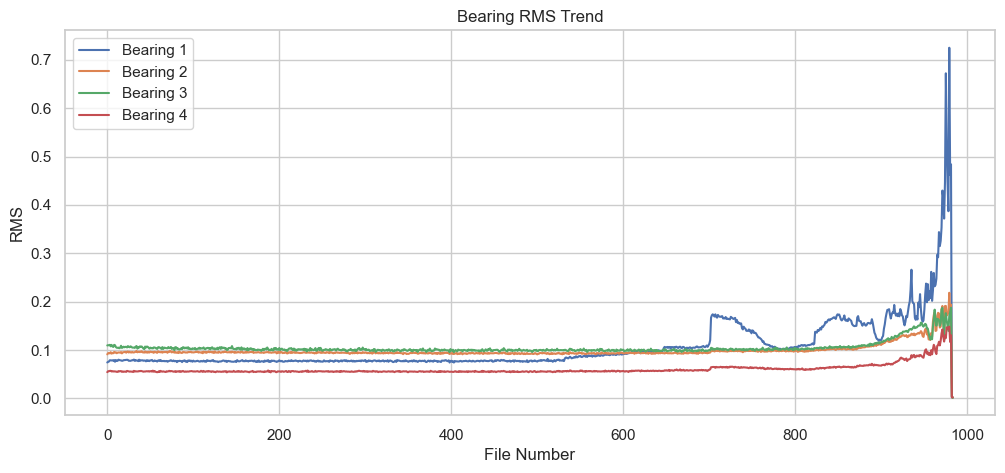

In [13]:
# ----------------------------------
# RMS Trend
# ----------------------------------

plt.figure(figsize=(12,5))

plt.plot(

    ims_features["Bearing_1_RMS"],

    label="Bearing 1"

)

plt.plot(

    ims_features["Bearing_2_RMS"],

    label="Bearing 2"

)

plt.plot(

    ims_features["Bearing_3_RMS"],

    label="Bearing 3"

)

plt.plot(

    ims_features["Bearing_4_RMS"],

    label="Bearing 4"

)

plt.xlabel("File Number")

plt.ylabel("RMS")

plt.title("Bearing RMS Trend")

plt.legend()

plt.show()

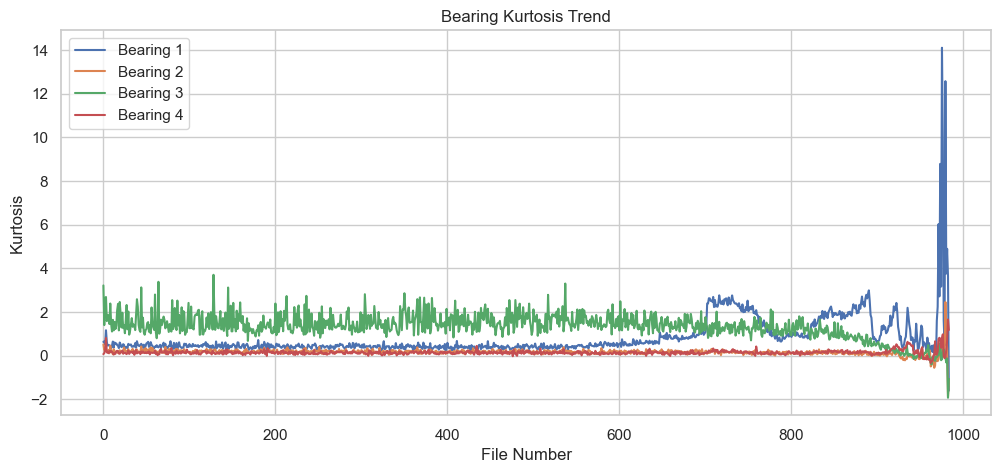

In [14]:
# ----------------------------------
# Kurtosis Trend
# ----------------------------------

plt.figure(figsize=(12,5))

plt.plot(

    ims_features["Bearing_1_Kurtosis"],

    label="Bearing 1"

)

plt.plot(

    ims_features["Bearing_2_Kurtosis"],

    label="Bearing 2"

)

plt.plot(

    ims_features["Bearing_3_Kurtosis"],

    label="Bearing 3"

)

plt.plot(

    ims_features["Bearing_4_Kurtosis"],

    label="Bearing 4"

)

plt.xlabel("File Number")

plt.ylabel("Kurtosis")

plt.title("Bearing Kurtosis Trend")

plt.legend()

plt.show()

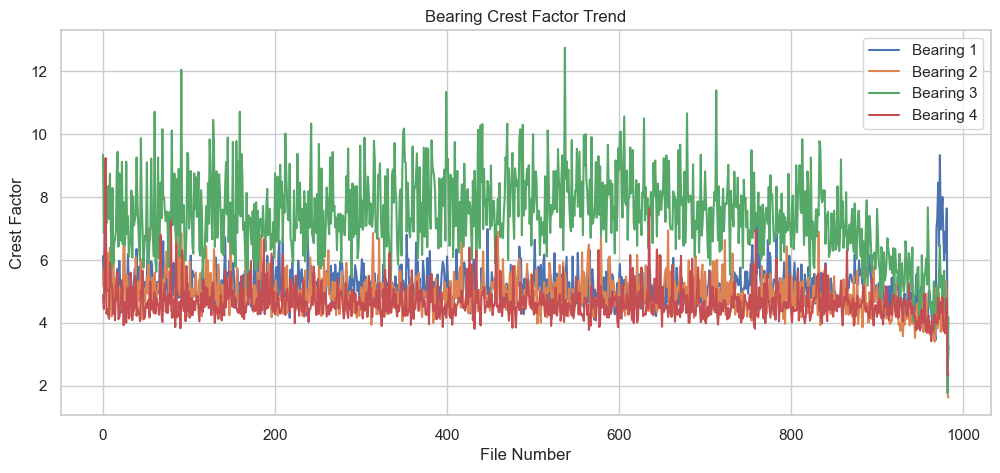

In [15]:
# ----------------------------------
# Crest Factor Trend
# ----------------------------------

plt.figure(figsize=(12,5))

plt.plot(

    ims_features["Bearing_1_Crest"],

    label="Bearing 1"

)

plt.plot(

    ims_features["Bearing_2_Crest"],

    label="Bearing 2"

)

plt.plot(

    ims_features["Bearing_3_Crest"],

    label="Bearing 3"

)

plt.plot(

    ims_features["Bearing_4_Crest"],

    label="Bearing 4"

)

plt.xlabel("File Number")

plt.ylabel("Crest Factor")

plt.title("Bearing Crest Factor Trend")

plt.legend()

plt.show()

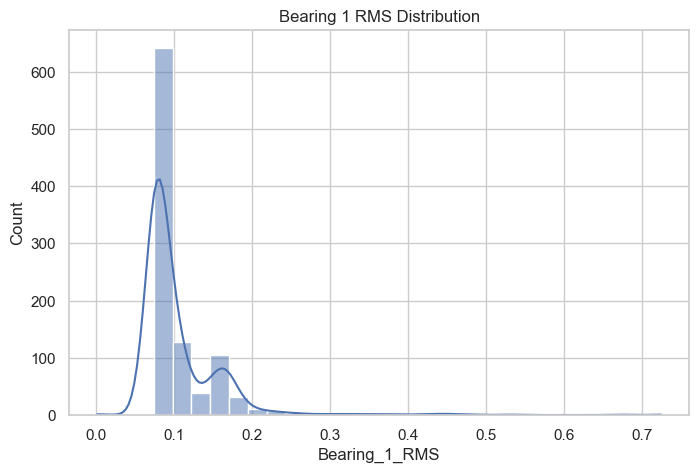

In [16]:
# ----------------------------------
# RMS Distribution
# ----------------------------------

plt.figure(figsize=(8,5))

sns.histplot(

    ims_features["Bearing_1_RMS"],

    bins=30,

    kde=True

)

plt.title("Bearing 1 RMS Distribution")

plt.show()

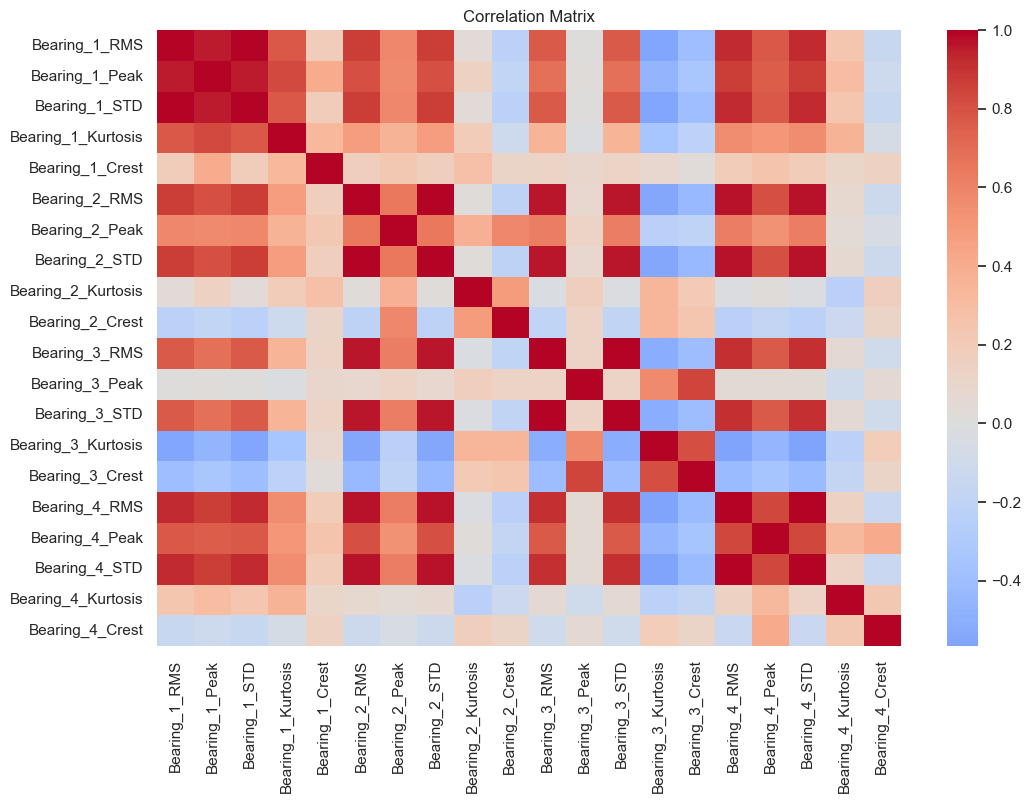

In [17]:
# ----------------------------------
# Correlation Between Indicators
# ----------------------------------

plt.figure(figsize=(12,8))

sns.heatmap(

    ims_features.drop(columns="File").corr(),

    cmap="coolwarm",

    center=0

)

plt.title("Correlation Matrix")

plt.show()

In [18]:
# ----------------------------------
# Highest Vibration Records
# ----------------------------------

ims_features.sort_values(

    by="Bearing_1_RMS",

    ascending=False

).head(10)

,File,Bearing_1_RMS,Bearing_1_Peak,Bearing_1_STD,Bearing_1_Kurtosis,Bearing_1_Crest,Bearing_2_RMS,Bearing_2_Peak,Bearing_2_STD,Bearing_2_Kurtosis,...,Bearing_3_RMS,Bearing_3_Peak,Bearing_3_STD,Bearing_3_Kurtosis,Bearing_3_Crest,Bearing_4_RMS,Bearing_4_Peak,Bearing_4_STD,Bearing_4_Kurtosis,Bearing_4_Crest
979,2004.02.19.05.42.39,0.725001,5.000,0.724996,12.577705,6.896538,0.218294,1.118,0.218293,2.452739,...,0.170577,0.769,0.170566,-0.098037,4.508234,0.148351,0.544,0.148322,-0.093287,3.666976
975,2004.02.19.05.02.39,0.672137,5.000,0.672129,14.110009,7.438954,0.191075,0.852,0.191073,0.474303,...,0.176179,0.969,0.176175,-0.163399,5.500103,0.124645,0.547,0.124598,0.786019,4.388470
976,2004.02.19.05.12.39,0.530956,4.250,0.530930,9.796461,8.004428,0.171075,0.754,0.171063,0.618246,...,0.160426,0.715,0.160415,0.150352,4.456874,0.146894,0.706,0.146858,0.970249,4.806179
981,2004.02.19.06.02.39,0.483835,3.696,0.483832,4.891755,7.638962,0.193641,0.891,0.193634,0.330627,...,0.187405,0.845,0.187400,-0.135662,4.508940,0.130582,0.625,0.130540,0.697167,4.786252
980,2004.02.19.05.52.39,0.462012,2.881,0.461990,3.759972,6.235773,0.170817,0.908,0.170814,0.911258,...,0.177878,0.764,0.177873,-0.319206,4.295083,0.116630,0.527,0.116583,0.259591,4.518571
974,2004.02.19.04.52.39,0.447673,3.120,0.447666,3.161553,6.969376,0.190857,0.708,0.190849,-0.061346,...,0.165213,0.847,0.165188,-0.214014,5.126723,0.129910,0.562,0.129864,0.358092,4.326071
977,2004.02.19.05.22.39,0.445918,3.066,0.445907,1.624278,6.875700,0.173196,0.676,0.173189,0.128312,...,0.149478,0.796,0.149464,0.282709,5.325213,0.146420,0.549,0.146387,-0.042612,3.749481
971,2004.02.19.04.22.39,0.429678,3.635,0.429673,6.022867,8.459815,0.190952,0.771,0.190949,-0.166077,...,0.187382,0.879,0.187361,0.013628,4.690956,0.142444,0.684,0.142417,0.760694,4.801878
972,2004.02.19.04.32.39,0.415570,2.678,0.415563,2.710835,6.444164,0.162813,0.806,0.162803,0.156734,...,0.155399,0.879,0.155378,0.465218,5.656392,0.127834,0.527,0.127804,0.813460,4.122536
978,2004.02.19.05.32.39,0.386975,2.317,0.386975,0.468857,5.987469,0.176702,0.769,0.176685,0.099268,...,0.139409,0.789,0.139393,0.126481,5.659605,0.143399,0.542,0.143374,-0.116769,3.779664


In [19]:
# ----------------------------------
# Save Processed IMS Dataset
# ----------------------------------

ims_features.to_csv(

    "IMS_Vibration_Features.csv",

    index=False

)

print("IMS vibration features saved successfully.")

IMS vibration features saved successfully.
